# 02 - Scoring model

Este notebook importa `calcular_score` desde `src.scoring.compute_score`; no reimplementa la fórmula validada.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATASET = ROOT / 'data' / 'GTM-Engineer-BC-Dataset.xlsx'
TOP50 = ROOT / 'analysis' / 'top50.csv'
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 5)

universo = pd.read_excel(DATASET, sheet_name='universo_potencial')
xsell = pd.read_excel(DATASET, sheet_name='bnpl_xsell_sample')
funnel = pd.read_excel(DATASET, sheet_name='funnel_snapshot')
top50 = pd.read_csv(TOP50)

con = duckdb.connect()
con.register('universo', universo)
con.register('xsell', xsell)
con.register('funnel_snapshot', funnel)
con.register('top50', top50)
print({'universo': universo.shape, 'xsell': xsell.shape, 'funnel': funnel.shape, 'top50': top50.shape})

from src.scoring.compute_score import calcular_score
from src.scoring.validators import run_all_validations
from src.scoring.constants import TIER_A_SIZE, TIER_B_SIZE

{'universo': (5000, 16), 'xsell': (2500, 13), 'funnel': (150, 13), 'top50': (50, 15)}


## Fórmula validada

Para Tier B:

$$
fit\_score = PCTL(gmv\_{12m})\cdot\frac{30}{55} + PCTL(n\_unique\_clients)\cdot\frac{15}{55} + (100 - PCTL(|ticket - 275000|))\cdot\frac{10}{55}
$$

$$
momentum\_score = \frac{\min(gmv\_{90d}\times 4 / gmv\_{12m}, 2.0)}{2.0}\times 100
$$

$$
recency\_score = e^{-days\_since\_last\_orig/30}\times 100
$$

$$
category\_bonus = \begin{cases}10 & BPI < 12\% \\ 5 & BPI < 19\% \\ 0 & BPI \ge 19\%\end{cases}
$$

$$
final\_score = fit\cdot0.55 + momentum\cdot0.25 + recency\cdot0.05 + category\_bonus
$$

In [2]:
scored = calcular_score(DATASET)
scored.head(20)

,rank,brand_id,tier,category,gmv_cop_millions_12m,n_unique_clients_12m,gmv_90d_to_12m_ratio,days_since_last_orig,recency_score,fit_score,momentum_score,category_bonus,final_score,why,routing
0,1,Brand_0002,A,Tecnología,134431,84892,NaN,1,NaN,NaN,NaN,NaN,NaN,"Top 15 GMV puro: COP 134,431 MM",KAM/Hunter Sr
1,2,Brand_0004,A,Moda,94270,146577,NaN,0,NaN,NaN,NaN,NaN,NaN,"Top 15 GMV puro: COP 94,270 MM",KAM/Hunter Sr
2,3,Brand_0005,A,Moda,79572,142077,NaN,0,NaN,NaN,NaN,NaN,NaN,"Top 15 GMV puro: COP 79,572 MM",KAM/Hunter Sr
3,4,Brand_0008,A,Moda,72807,217144,NaN,0,NaN,NaN,NaN,NaN,NaN,"Top 15 GMV puro: COP 72,807 MM",KAM/Hunter Sr
4,5,Brand_0011,A,Moda,57769,154336,NaN,0,NaN,NaN,NaN,NaN,NaN,"Top 15 GMV puro: COP 57,769 MM",KAM/Hunter Sr
5,6,Brand_0012,A,Telecomunicaciones,52822,34433,NaN,1,NaN,NaN,NaN,NaN,NaN,"Top 15 GMV puro: COP 52,822 MM",KAM/Hunter Sr
6,7,Brand_0016,A,Hogar,37123,24982,NaN,1,NaN,NaN,NaN,NaN,NaN,"Top 15 GMV puro: COP 37,123 MM",KAM/Hunter Sr
7,8,Brand_0019,A,Hogar,36178,27916,NaN,1,NaN,NaN,NaN,NaN,NaN,"Top 15 GMV puro: COP 36,178 MM",KAM/Hunter Sr
8,9,Brand_0020,A,Moda,34528,89203,NaN,0,NaN,NaN,NaN,NaN,NaN,"Top 15 GMV puro: COP 34,528 MM",KAM/Hunter Sr
9,10,Brand_0022,A,Vehículos y autopartes,29019,7291,NaN,3,NaN,NaN,NaN,NaN,NaN,"Top 15 GMV puro: COP 29,019 MM",KAM/Hunter Sr


## Sensibilidad de pesos ±10pp

In [3]:
base = calcular_score(DATASET)
base_top50 = set(base['brand_id'])
base_weights = {'fit': 0.55, 'momentum': 0.25, 'recency': 0.05, 'category_bonus': 1.0}
rows = []
for component in ['fit', 'momentum', 'recency']:
    for delta in [-0.10, 0.10]:
        weights = base_weights.copy()
        weights[component] = max(0, weights[component] + delta)
        variant = calcular_score(DATASET, weights=weights)
        overlap = len(base_top50.intersection(set(variant['brand_id']))) / len(base_top50) * 100
        rows.append({'component': component, 'delta_pp': int(delta * 100), 'overlap_top50_pct': overlap})
sensitivity = pd.DataFrame(rows)
sensitivity

,component,delta_pp,overlap_top50_pct
0,fit,-10,90.0
1,fit,10,92.0
2,momentum,-10,76.0
3,momentum,10,84.0
4,recency,-10,98.0
5,recency,10,100.0


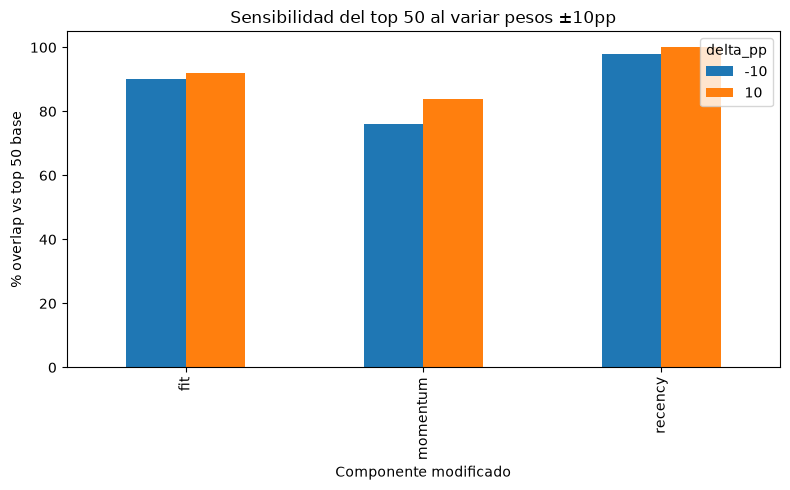

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot = sensitivity.pivot(index='component', columns='delta_pp', values='overlap_top50_pct')
pivot.plot(kind='bar', ax=ax)
ax.set_title('Sensibilidad del top 50 al variar pesos ±10pp')
ax.set_xlabel('Componente modificado')
ax.set_ylabel('% overlap vs top 50 base')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## Distribución de final_score

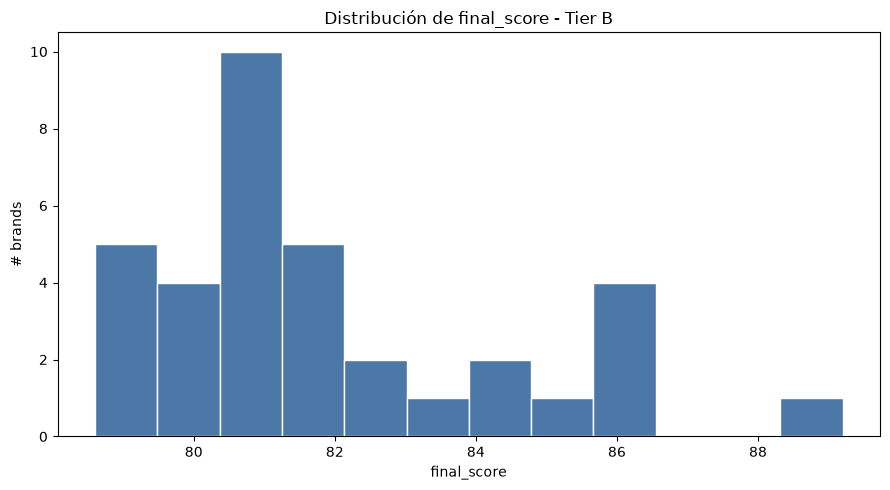

In [5]:
tier_b = scored[scored['tier'].eq('B')].copy()
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(tier_b['final_score'], bins=12, color='#4c78a8', edgecolor='white')
ax.set_title('Distribución de final_score - Tier B')
ax.set_xlabel('final_score')
ax.set_ylabel('# brands')
plt.tight_layout()
plt.show()

## Scatter GMV vs momentum coloreado por tier

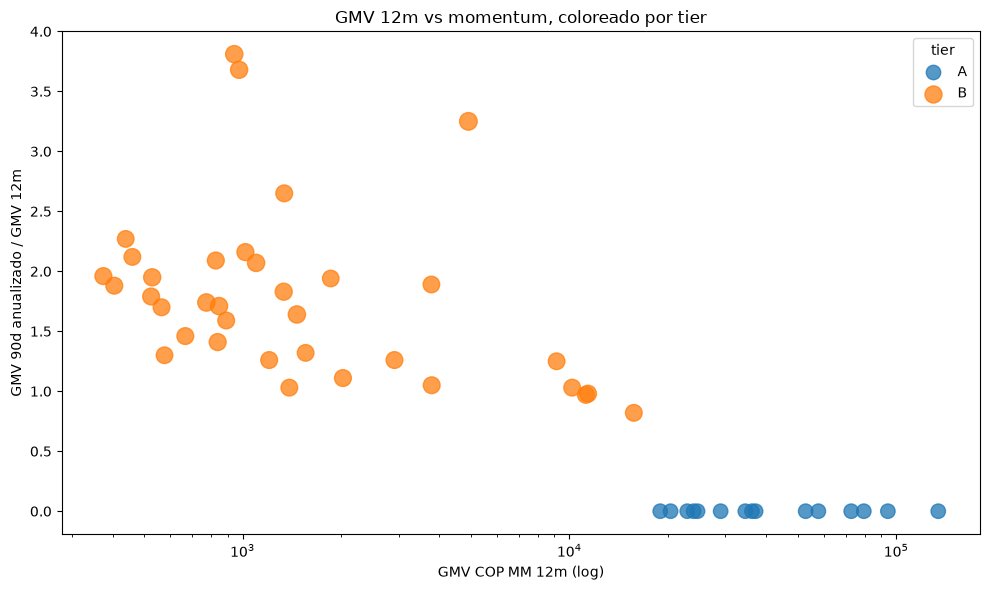

In [6]:
plot_df = scored.copy()
plot_df['gmv_90d_to_12m_ratio_plot'] = plot_df['gmv_90d_to_12m_ratio'].fillna(0)
fig, ax = plt.subplots(figsize=(10, 6))
for tier, group in plot_df.groupby('tier'):
    sizes = group['final_score'].fillna(60).clip(lower=20) * 1.8
    ax.scatter(group['gmv_cop_millions_12m'], group['gmv_90d_to_12m_ratio_plot'], s=sizes, label=tier, alpha=0.75)
ax.legend(title='tier')
ax.set_xscale('log')
ax.set_title('GMV 12m vs momentum, coloreado por tier')
ax.set_xlabel('GMV COP MM 12m (log)')
ax.set_ylabel('GMV 90d anualizado / GMV 12m')
plt.tight_layout()
plt.show()

## Validaciones: 8 asserts

In [7]:
validation_results = run_all_validations(scored, universo)
validation_df = pd.DataFrame([{
    'assert': r.name,
    'status': 'PASS' if r.passed else 'FAIL',
    'detail': r.detail,
} for r in validation_results])
validation_df

,assert,status,detail
0,sin_duplicados,PASS,0 duplicados
1,sin_categorias_excluidas,PASS,0 categorias excluidas
2,tier_a_top15_exacto,PASS,Tier A coincide con top 15 GMV
3,fit_score_signo,PASS,corr=0.568
4,momentum_score_signo,PASS,corr=0.809
5,recency_score_signo,PASS,corr=-1.000
6,cap_categoria_tier_b,PASS,"max_count=14, max_allowed=14"
7,gmv_coincide_dataset,PASS,todos coinciden


In [8]:
assert validation_df['status'].eq('PASS').all(), validation_df.to_string(index=False)
print('8/8 asserts PASS')

8/8 asserts PASS
